In [44]:

import pandas as pd
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE

In [2]:
telecom_df1 = pd.read_csv('./telecom.csv')
telecom_df1

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,No,No,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False


In [3]:
telecom_df2 = pd.read_csv('./telecom2.csv')
telecom_df2

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
datos_personales = telecom_df2.sample(len(telecom_df1)).copy()
datos_operativos = telecom_df1.copy()

In [5]:
datos_personales.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3153,9099-FTUHS,Female,0,No,No,23,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,No,Electronic check,54.40,1249.25,No
3144,7968-QUXNS,Male,0,No,No,6,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,18.95,110.15,No
5902,7054-ENNGU,Female,0,Yes,No,9,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,50.85,466.6,No
719,6952-OMNWB,Male,1,Yes,No,68,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),80.35,5589.3,No
2232,6479-SZPLM,Male,0,Yes,Yes,36,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.45,754.5,No


In [6]:
datos_personales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2666 entries, 5324 to 504
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        2666 non-null   object 
 1   gender            2666 non-null   object 
 2   SeniorCitizen     2666 non-null   int64  
 3   Partner           2666 non-null   object 
 4   Dependents        2666 non-null   object 
 5   tenure            2666 non-null   int64  
 6   PhoneService      2666 non-null   object 
 7   MultipleLines     2666 non-null   object 
 8   InternetService   2666 non-null   object 
 9   OnlineSecurity    2666 non-null   object 
 10  OnlineBackup      2666 non-null   object 
 11  DeviceProtection  2666 non-null   object 
 12  TechSupport       2666 non-null   object 
 13  StreamingTV       2666 non-null   object 
 14  StreamingMovies   2666 non-null   object 
 15  Contract          2666 non-null   object 
 16  PaperlessBilling  2666 non-null   object 
 17

In [7]:
datos_personales.InternetService.unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [8]:
datos_personales.Partner.unique()

array(['No', 'Yes'], dtype=object)

In [9]:
#Converitir-codificar vaariables texto a numerico
datos_personales['Partner'] = [1 if dato == 'Yes' else 0 for dato in  datos_personales['Partner'] ]
datos_personales['Female'] = [1 if dato == 'Female' else 0 for dato in  datos_personales['gender'] ]
datos_personales['SeniorCitizen'] = [1 if dato == 'Yes' else 0 for dato in  datos_personales['SeniorCitizen'] ]
datos_personales['MultipleLines'] = [1 if dato == 'Yes' else 0 for dato in  datos_personales['MultipleLines'] ]
datos_personales['Dependents'] = [1 if dato == 'Yes' else 0 for dato in datos_personales['Dependents'] ]
datos_personales.drop(columns=['gender'], inplace=True)

In [10]:
datos_personales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2666 entries, 5324 to 504
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        2666 non-null   object 
 1   SeniorCitizen     2666 non-null   int64  
 2   Partner           2666 non-null   int64  
 3   Dependents        2666 non-null   int64  
 4   tenure            2666 non-null   int64  
 5   PhoneService      2666 non-null   object 
 6   MultipleLines     2666 non-null   int64  
 7   InternetService   2666 non-null   object 
 8   OnlineSecurity    2666 non-null   object 
 9   OnlineBackup      2666 non-null   object 
 10  DeviceProtection  2666 non-null   object 
 11  TechSupport       2666 non-null   object 
 12  StreamingTV       2666 non-null   object 
 13  StreamingMovies   2666 non-null   object 
 14  Contract          2666 non-null   object 
 15  PaperlessBilling  2666 non-null   object 
 16  PaymentMethod     2666 non-null   object 
 17

In [11]:
datos_personales_de_interes = ['Female', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']


In [12]:
datos_operativos.sample(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
235,WI,96,510,No,Yes,18,172.7,86,29.36,133.4,113,11.34,259.5,70,11.68,9.8,3,2.65,1,False
35,MD,135,408,Yes,Yes,41,173.1,85,29.43,203.9,107,17.33,122.2,78,5.50,14.6,15,3.94,0,True
467,NM,104,415,No,No,0,164.2,109,27.91,155.4,90,13.21,168.9,117,7.60,10.7,8,2.89,1,False
12,IA,62,415,No,No,0,120.7,70,20.52,307.2,76,26.11,203.0,99,9.14,13.1,6,3.54,4,False
2571,OH,68,415,Yes,Yes,24,125.7,92,21.37,275.9,98,23.45,214.5,108,9.65,14.2,6,3.83,3,True


In [13]:
datos_operativos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [14]:
datos_operativos['International plan'] = [1 if dato == 'Yes' else 0 for dato in  datos_operativos['International plan'] ]

In [15]:
datos_operativos['Voice mail plan'] = [1 if dato == 'Yes' else 0 for dato in  datos_operativos['Voice mail plan'] ]

In [16]:
datos_operativos.drop(columns=['State', 'Account length', 'Area code', 'Churn'], inplace=True)

In [17]:
procesado = pd.concat([datos_operativos.reset_index(drop=True), datos_personales[datos_personales_de_interes].reset_index(drop=True)], axis=1)

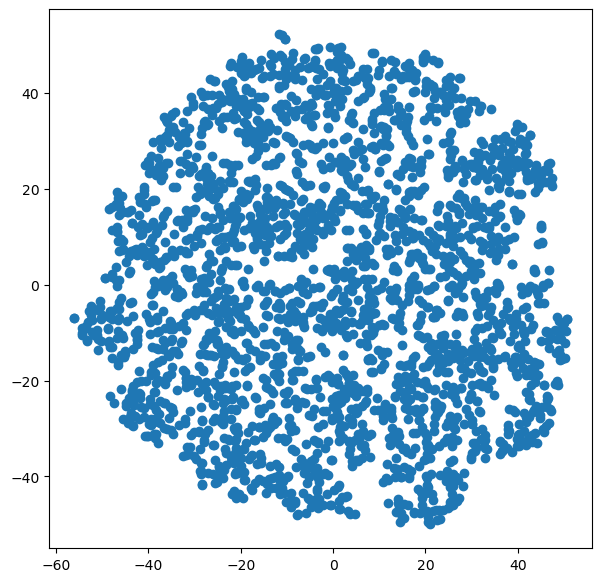

In [45]:
model = TSNE(n_components=2, random_state=0)
tsne_data = model.fit_transform(procesado)
plt.figure(figsize=(7, 7))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1])
plt.show()

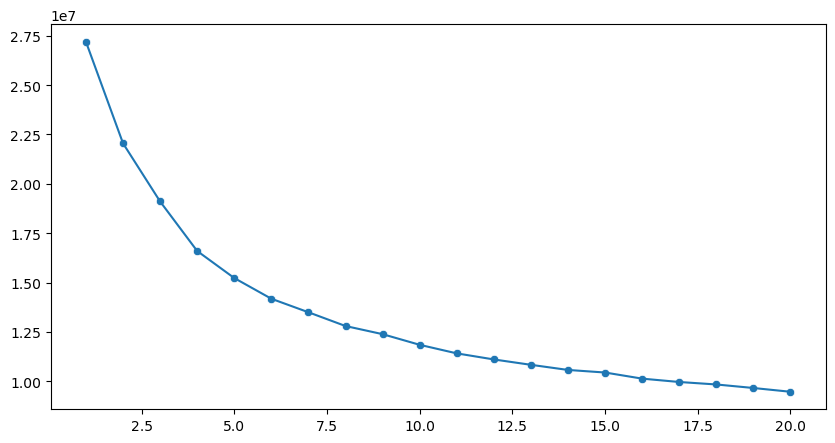

In [47]:
error = []
for n_clusters in range(1, 21):
    model = KMeans(init='k-means++',
                   n_clusters=n_clusters,
                   max_iter=500,
                   random_state=22)
    model.fit(procesado)
    error.append(model.inertia_)
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, 21), y=error)
sns.scatterplot(x=range(1, 21), y=error)
plt.show()

In [51]:
model = KMeans(init='k-means++',
               n_clusters=4,
               max_iter=500,
               random_state=22)
segments = model.fit_predict(procesado)

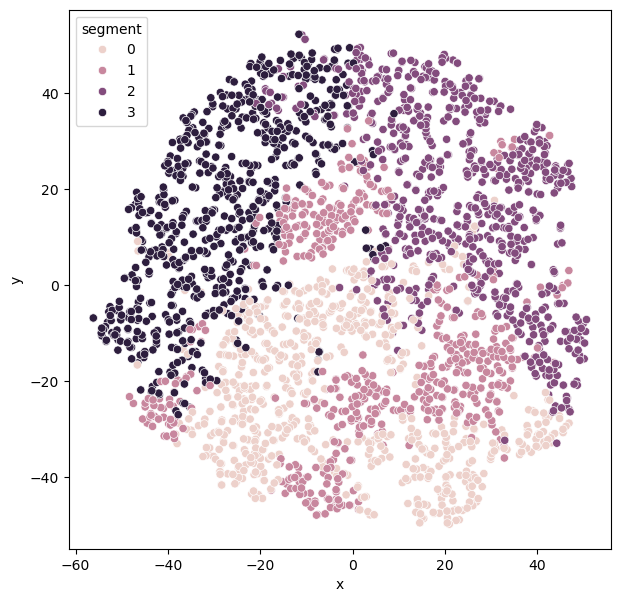

In [52]:
plt.figure(figsize=(7, 7))

df_tsne = pd.DataFrame({'x': tsne_data[:, 0], 'y': tsne_data[:, 1], 'segment': segments})

sns.scatterplot(x='x', y='y', hue='segment', data=df_tsne)
plt.show()

In [55]:
agrupados = procesado.copy()
agrupados['cluster'] = segments
agrupados

,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,...,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Female,SeniorCitizen,Partner,Dependents,tenure,cluster
0,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,...,10.0,3,2.70,1,0,0,0,0,24,2
1,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,...,13.7,3,3.70,1,0,0,0,0,17,0
2,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,...,12.2,5,3.29,0,0,0,0,0,9,1
3,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,...,6.6,7,1.78,2,1,0,0,0,6,1
4,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,...,10.1,3,2.73,3,1,0,1,0,57,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,0,0,0,134.7,98,22.90,189.7,68,16.12,221.4,...,11.8,5,3.19,2,0,0,1,0,1,3
2662,0,1,36,156.2,77,26.55,215.5,126,18.32,279.1,...,9.9,6,2.67,2,1,0,1,0,47,0
2663,0,0,0,231.1,57,39.29,153.4,55,13.04,191.3,...,9.6,4,2.59,3,0,0,1,1,15,1
2664,0,0,0,180.8,109,30.74,288.8,58,24.55,191.9,...,14.1,6,3.81,2,0,0,0,0,1,2


In [59]:
agrupados.groupby(by='cluster').mean()

,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,...,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Female,SeniorCitizen,Partner,Dependents,tenure
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.101865,0.288379,8.550933,174.706313,100.644189,29.700646,180.199713,100.252511,15.317145,256.558106,...,11.545308,10.313343,4.464849,2.785065,1.552367,0.486370,0.0,0.510760,0.328551,33.974175
1,0.095563,0.261092,7.658703,188.064846,101.085324,31.971399,150.140614,100.501706,12.762304,161.176280,...,7.253089,10.124061,4.489761,2.734096,1.580205,0.511945,0.0,0.494881,0.303754,31.090444
2,0.112500,0.291667,8.645833,229.622222,99.802778,39.036306,234.331528,99.377778,19.918417,194.880000,...,8.769542,10.199722,4.440278,2.754486,1.530556,0.502778,0.0,0.498611,0.283333,34.009722
3,0.093514,0.254902,7.108597,122.464103,99.825038,20.819517,229.154148,100.061840,19.478356,185.116893,...,8.330332,10.297134,4.479638,2.780588,1.592760,0.473605,0.0,0.475113,0.304676,31.218703
